# ARX Baseline V1

Notebook này là bản baseline cơ bản nhất của pipeline ARX. Mục tiêu là fit model `ARX(2,2,1)` với 6 input gốc, OLS, không intercept, không log transform, không feature engineering, không clip và không regularization.

Đây là mốc gốc để so sánh với các bản cải tiến sau.

## 1. Import thư viện và hàm pipeline

Notebook dùng lại các hàm trong `arx_pipeline.py` để tránh viết lại logic fit/evaluate.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arx_pipeline import (
    DataConfig,
    SplitConfig,
    ModelConfig,
    load_or_generate_data,
    split_time_series,
    summarize_dataset_behavior,
    build_regression_matrix,
    estimate_ols,
    build_true_theta,
    evaluate_slice,
    summarize_parameters,
    compute_ar_roots,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## 2. Cấu hình baseline

Baseline V1 có cấu hình:

- `ARX(2,2,1)`
- 6 input gốc: `Temperature`, `Humidity`, `Light`, `Drip`, `Mist`, `Fan`
- `include_intercept=False`
- `simulation_clip=None`
- Fit bằng OLS

In [3]:
DATA_CONFIG = DataConfig(
    csv_path=Path("greenhouse_data.csv"),
    generator_script_path=Path("data_generator.py"),
    force_regenerate_from_script=False,
    auto_save_generated_csv=True,
)

SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)

BASELINE_INPUT_COLS = (
    "Temperature",
    "Humidity",
    "Light",
    "Drip",
    "Mist",
    "Fan",
)

BASELINE_CONFIG = ModelConfig(
    na=2,
    nb=2,
    nk=1,
    include_intercept=False,
    input_cols=BASELINE_INPUT_COLS,
    output_col="Soil_Moisture",
    simulation_clip=None,
)

BASELINE_CONFIG

ModelConfig(na=2, nb=2, nk=1, include_intercept=False, input_cols=('Temperature', 'Humidity', 'Light', 'Drip', 'Mist', 'Fan'), output_col='Soil_Moisture', simulation_clip=None)

## 3. Load data và chia train/validation/test

Data được chia theo thứ tự thời gian, không shuffle.

In [4]:
df_full, true_params, data_source = load_or_generate_data(DATA_CONFIG)
df_train, df_val, df_test = split_time_series(df_full, SPLIT_CONFIG)

overview = pd.DataFrame([
    summarize_dataset_behavior(df_full, "Full"),
    summarize_dataset_behavior(df_train, "Train"),
    summarize_dataset_behavior(df_val, "Validation"),
    summarize_dataset_behavior(df_test, "Test"),
])

print("Nguồn dữ liệu:", data_source)
print("Số dòng:", len(df_full), "| Train:", len(df_train), "| Validation:", len(df_val), "| Test:", len(df_test))
overview

Nguồn dữ liệu: CSV:greenhouse_data.csv
Số dòng: 105120 | Train: 63072 | Validation: 21024 | Test: 21024


,label,rows,timestamp_start,timestamp_end,months_present,seasons_present,drip_on_pct,drip_switches,mist_on_pct,mist_switches,fan_on_pct,fan_switches,below_sp_pct,inside_sp_pct,above_sp_pct
0,Full,105120,2025-01-01 00:00:00,2025-12-31 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[autumn, spring, summer, winter]",22.80,12533,7.89,8022,16.89,12768,23.09,76.35,0.56
1,Train,63072,2025-01-01 00:00:00,2025-08-07 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8]","[spring, summer, winter]",22.95,7546,7.81,4760,17.46,7865,23.30,76.13,0.57
2,Validation,21024,2025-08-08 00:00:00,2025-10-19 23:55:00,"[8, 9, 10]","[autumn, summer]",23.47,2558,9.77,1970,19.34,2817,23.84,75.75,0.41
3,Test,21024,2025-10-20 00:00:00,2025-12-31 23:55:00,"[10, 11, 12]","[autumn, winter]",21.68,2429,6.25,1292,12.75,2085,21.70,77.61,0.69


## 4. Xem nhanh tín hiệu đầu vào/đầu ra

Bước này chỉ để kiểm tra data, chưa có bất kỳ feature engineering nào.

In [5]:
display(df_full[["Timestamp", "Soil_Moisture", *BASELINE_INPUT_COLS]].head())
display(df_full[["Soil_Moisture", *BASELINE_INPUT_COLS]].describe().T)

,Timestamp,Soil_Moisture,Temperature,Humidity,Light,Drip,Mist,Fan
0,2025-01-01 00:00:00,58.000000,20.778462,83.333673,1.168667,0.0,0.0,0.0
1,2025-01-01 00:05:00,57.800000,19.725025,82.264886,2.256788,0.0,0.0,0.0
2,2025-01-01 00:10:00,57.632050,19.696345,82.314817,20.575650,0.0,0.0,0.0
3,2025-01-01 00:15:00,57.198894,19.701227,82.287578,25.108612,0.0,0.0,0.0
4,2025-01-01 00:20:00,56.725747,19.837379,83.482156,7.002633,0.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
Soil_Moisture,105120.0,57.088944,3.324287,48.059576,54.614033,57.043236,59.502220,69.954344
Temperature,105120.0,25.694370,3.506181,14.000000,23.719480,26.967043,28.287723,32.248679
Humidity,105120.0,73.396990,8.047007,30.000000,68.287079,74.343021,79.989981,92.682276
Light,105120.0,287.285850,341.949416,0.000000,9.513857,27.891915,603.818208,1182.912024
Drip,105120.0,0.227997,0.419542,0.000000,0.000000,0.000000,0.000000,1.000000
Mist,105120.0,0.078919,0.269614,0.000000,0.000000,0.000000,0.000000,1.000000
Fan,105120.0,0.168950,0.374709,0.000000,0.000000,0.000000,0.000000,1.000000


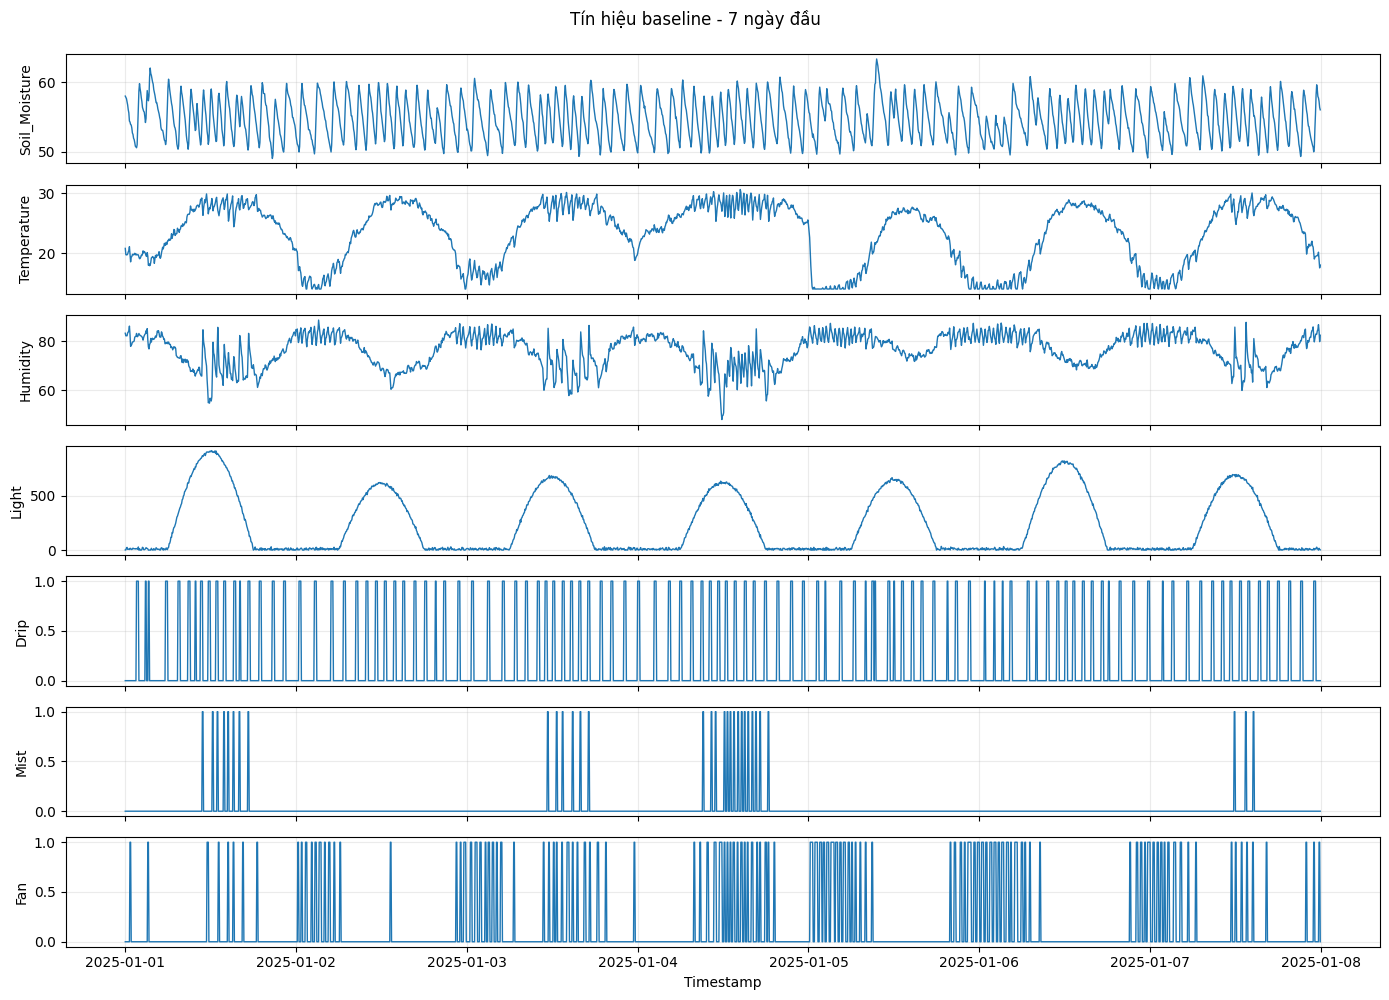

In [6]:
plot_cols = ["Soil_Moisture", "Temperature", "Humidity", "Light", "Drip", "Mist", "Fan"]
sample = df_full.iloc[: 7 * 24 * 12].copy()  # 7 ngày đầu, 5 phút/mẫu => 12 mẫu/giờ

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, plot_cols):
    ax.plot(sample["Timestamp"], sample[col], linewidth=1.0)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel("Timestamp")
fig.suptitle("Tín hiệu baseline - 7 ngày đầu", y=0.995)
fig.tight_layout()
plt.show()

## 5. Tạo regression matrix cho ARX(2,2,1)

Với 6 input gốc và `na=2`, `nb=2`, `nk=1`, mỗi dòng hồi quy gồm 14 cột:

- `y(t-1)`, `y(t-2)`
- mỗi input có `u(t-1)`, `u(t-2)`

Không có intercept trong baseline V1.

In [7]:
X_train, y_train = build_regression_matrix(df_train, BASELINE_CONFIG)

print("Kích thước X_train:", X_train.shape)
print("Kích thước y_train:", y_train.shape)
print("Tên tham số:")
for name in BASELINE_CONFIG.param_names:
    print(" -", name)

Kích thước X_train: (63070, 14)
Kích thước y_train: (63070,)
Tên tham số:
 - a1
 - a2
 - b_Temperature_1
 - b_Temperature_2
 - b_Humidity_1
 - b_Humidity_2
 - b_Light_1
 - b_Light_2
 - b_Drip_1
 - b_Drip_2
 - b_Mist_1
 - b_Mist_2
 - b_Fan_1
 - b_Fan_2


## 6. Fit OLS

Baseline V1 dùng least squares trực tiếp:

```text
theta = argmin ||y - X theta||^2
```

In [8]:
theta_hat, cov_hat, sigma2_hat = estimate_ols(X_train, y_train)
true_theta = build_true_theta(true_params, BASELINE_CONFIG)

print("sigma2_hat:", sigma2_hat)
print("Số lượng theta:", len(theta_hat))

sigma2_hat: 0.0624803163637758
Số lượng theta: 14


## 7. Bảng tham số baseline

Nếu data generator cung cấp true params, bảng này sẽ có cột đối chiếu với giá trị thật.

In [9]:
param_df = pd.DataFrame(summarize_parameters(theta_hat, cov_hat, BASELINE_CONFIG, true_params))
param_df

,name,estimate,std,ci95_low,ci95_high,true_value,delta_vs_true,sign_ok
0,a1,0.963098,0.001670,0.959824,0.966371,0.96500,-0.001902,True
1,a2,0.026738,0.001724,0.023358,0.030118,0.02500,0.001738,True
2,b_Temperature_1,-0.007410,0.002548,-0.012403,-0.002416,-0.00800,0.000590,True
3,b_Temperature_2,-0.003922,0.002493,-0.008808,0.000964,-0.00400,0.000078,True
4,b_Humidity_1,0.002567,0.000836,0.000929,0.004206,0.00250,0.000067,True
5,b_Humidity_2,0.001029,0.000825,-0.000588,0.002646,0.00120,-0.000171,True
6,b_Light_1,-0.000132,0.000070,-0.000270,0.000005,-0.00022,0.000088,True
7,b_Light_2,-0.000194,0.000071,-0.000334,-0.000055,-0.00010,-0.000094,True
8,b_Drip_1,1.251167,0.003388,1.244526,1.257809,1.25000,0.001167,True
9,b_Drip_2,1.851585,0.005452,1.840899,1.862271,1.85000,0.001585,True


## 8. Đánh giá Train / Validation / Test

Notebook hiển thị 3 nhóm metric:

- `1step`: dự đoán 1 bước, mỗi bước dùng output thật.
- `12step`: dự đoán ngắn hạn 12 bước.
- `sim`: free-run simulation, model tự dùng output dự đoán của chính nó.

In [10]:
train_eval = evaluate_slice("Train", df_train, theta_hat, BASELINE_CONFIG, true_theta=true_theta, n_step=12)
val_eval = evaluate_slice("Validation", df_val, theta_hat, BASELINE_CONFIG, true_theta=true_theta, n_step=12)
test_eval = evaluate_slice("Test", df_test, theta_hat, BASELINE_CONFIG, true_theta=true_theta, n_step=12)

def metric_row(split_name, ev):
    return {
        "split": split_name,
        "FIT_1step": ev["metrics_1step"]["FIT"],
        "RMSE_1step": ev["metrics_1step"]["RMSE"],
        "FIT_12step": ev["metrics_n_step"]["FIT"],
        "RMSE_12step": ev["metrics_n_step"]["RMSE"],
        "FIT_sim": ev["metrics_sim"]["FIT"],
        "RMSE_sim": ev["metrics_sim"]["RMSE"],
        "Bias_sim": ev["metrics_sim"]["Bias"],
    }

metrics_df = pd.DataFrame([
    metric_row("Train", train_eval),
    metric_row("Validation", val_eval),
    metric_row("Test", test_eval),
]).round(4)

metrics_df

,split,FIT_1step,RMSE_1step,FIT_12step,RMSE_12step,FIT_sim,RMSE_sim,Bias_sim
0,Train,92.5471,0.2499,76.4447,0.7899,49.5463,1.6920,0.0022
1,Validation,91.6406,0.2510,73.1094,0.8073,42.9588,1.7124,0.1490
2,Test,91.3491,0.2520,72.6736,0.7959,43.8749,1.6347,0.0479


## 9. Vẽ free-run simulation

`FIT_sim` là metric quan trọng nhất cho baseline vì nó cho thấy khả năng model mô phỏng động học khi không được cấp lại output thật ở mỗi bước.

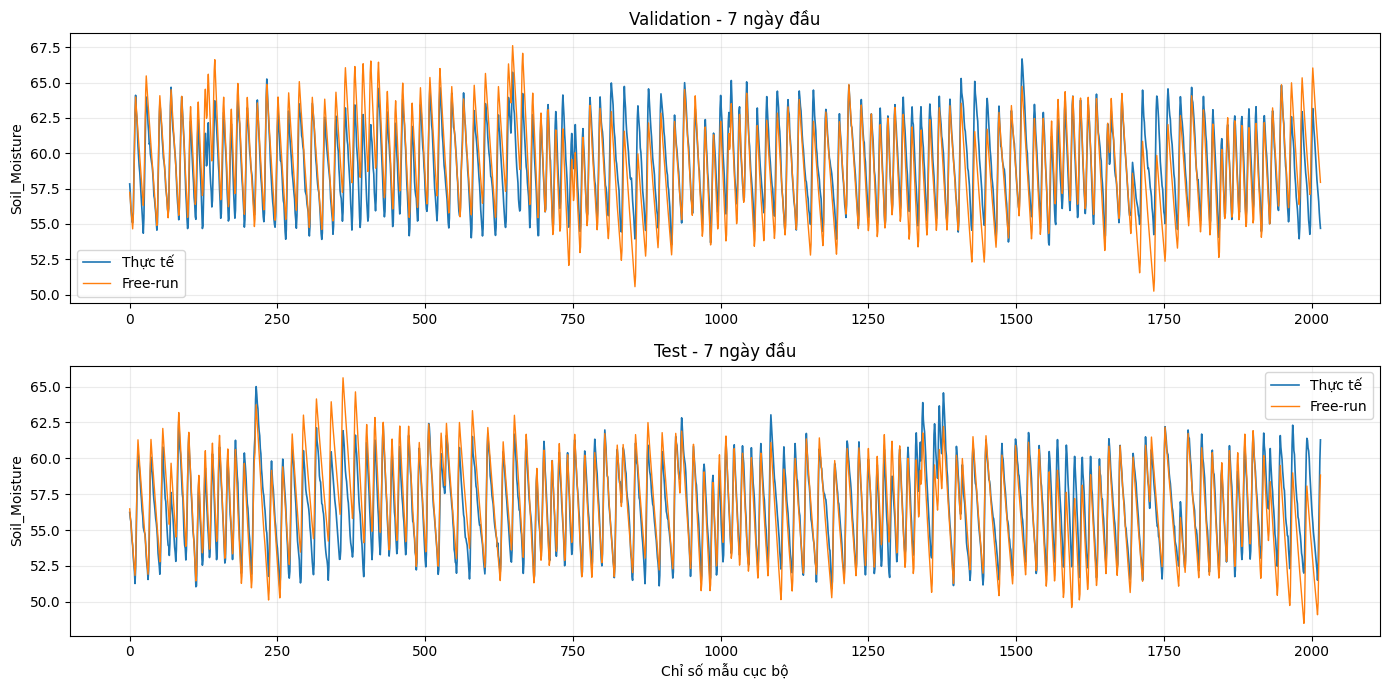

In [11]:
def prediction_frame(ev, split_name):
    n = len(ev["arrays"]["y_true_sim"])
    return pd.DataFrame({
        "split": split_name,
        "idx": np.arange(n),
        "y_true": ev["arrays"]["y_true_sim"],
        "y_pred_sim": ev["arrays"]["y_pred_sim"],
        "y_pred_12step": ev["arrays"]["y_pred_n_step"],
    })

pred_val = prediction_frame(val_eval, "Validation")
pred_test = prediction_frame(test_eval, "Test")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, pred_df, title in [
    (axes[0], pred_val.iloc[: 7 * 24 * 12], "Validation - 7 ngày đầu"),
    (axes[1], pred_test.iloc[: 7 * 24 * 12], "Test - 7 ngày đầu"),
]:
    ax.plot(pred_df["idx"], pred_df["y_true"], label="Thực tế", linewidth=1.2)
    ax.plot(pred_df["idx"], pred_df["y_pred_sim"], label="Free-run", linewidth=1.0)
    ax.set_title(title)
    ax.set_ylabel("Soil_Moisture")
    ax.grid(True, alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Chỉ số mẫu cục bộ")
fig.tight_layout()
plt.show()

## 10. Residual diagnostics

Đây là diagnostic trên residual 1-step. Baseline tốt hay không không chỉ nhìn FIT, mà còn cần xem residual có bias, tự tương quan và liên hệ với input hay không.

In [12]:
diag_rows = []
for split_name, ev in [("Train", train_eval), ("Validation", val_eval), ("Test", test_eval)]:
    diag = ev["residual_diagnostics"]
    diag_rows.append({
        "split": split_name,
        "resid_mean": diag["mean"],
        "resid_std": diag["std"],
        "shapiro_p": diag["normality"].get("shapiro_pvalue"),
        "dagostino_p": diag["normality"].get("dagostino_pvalue"),
        "ljung_box_pass": diag["ljung_box"].get("passes_all_lags"),
        "failed_lags": diag["ljung_box"].get("failed_lags"),
    })

pd.DataFrame(diag_rows)

,split,resid_mean,resid_std,shapiro_p,dagostino_p,ljung_box_pass,failed_lags
0,Train,-0.000028,0.249933,0.764589,0.436970,True,[]
1,Validation,0.001619,0.250953,0.202405,0.411814,True,[]
2,Test,0.000488,0.251971,0.725888,0.114067,True,[]


## 11. Stability roots cho ARX(2,2,1)

Với `na=2`, pipeline có thể tính roots của phần tự hồi quy output. Root nằm trong/ngoài đơn vị giúp đánh giá tính ổn định động học.

In [13]:
ar_roots = compute_ar_roots(theta_hat, BASELINE_CONFIG)
pd.DataFrame(ar_roots)

,root_index,real,imag,magnitude
0,1,0.990103,0.0,0.990103
1,2,-0.027005,0.0,0.027005


## 12. Lưu artifact baseline V1

Artifact riêng cho baseline được lưu thành `arx_baseline_v1.json`. File này không thay thế artifact final.

In [14]:
def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_ready(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, Path):
        return str(value)
    return value

artifact = {
    "model_type": "ARX",
    "version": "v1_baseline_basic",
    "notes": "Baseline ARX(2,2,1), 6 raw inputs, OLS, no intercept, no feature engineering, no clip, no regularization.",
    "data_source": data_source,
    "data_config": DATA_CONFIG.__dict__,
    "split_config": SPLIT_CONFIG.__dict__,
    "model_config": BASELINE_CONFIG.__dict__,
    "param_names": BASELINE_CONFIG.param_names,
    "theta_hat": theta_hat.tolist(),
    "sigma2": sigma2_hat,
    "ar_roots": ar_roots,
    "metrics": {
        "train": {
            "fit_1": train_eval["metrics_1step"]["FIT"],
            "fit_12": train_eval["metrics_n_step"]["FIT"],
            "fit_sim": train_eval["metrics_sim"]["FIT"],
        },
        "validation": {
            "fit_1": val_eval["metrics_1step"]["FIT"],
            "fit_12": val_eval["metrics_n_step"]["FIT"],
            "fit_sim": val_eval["metrics_sim"]["FIT"],
        },
        "test": {
            "fit_1": test_eval["metrics_1step"]["FIT"],
            "fit_12": test_eval["metrics_n_step"]["FIT"],
            "fit_sim": test_eval["metrics_sim"]["FIT"],
        },
    },
}

output_path = Path("arx_baseline_v1.json")
with output_path.open("w", encoding="utf-8") as f:
    json.dump(json_ready(artifact), f, indent=2)
    f.write("\n")

output_path

WindowsPath('arx_baseline_v1.json')

## 13. Kết luận baseline V1

Baseline V1 là mốc gốc:

- ARX thuần, cấu trúc `2,2,1`.
- Chỉ dùng 6 input gốc.
- Không log transform, không interaction, không setpoint/season feature.
- Không clip free-run.
- Không normalize/regularization.

Các notebook v2/v3 sau có thể thêm từng nhóm cải tiến: intercept, `Light_log`, feature engineering, clip, `ARX(5,1,2)`, Ridge/Lasso và rolling validation.